In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px


In [ ]:
# Temizlenmiş veriyi okuyoruz
# Hatalı yol düzeltildi: ../../../ -> ../../
df_oyunlar = pd.read_csv("../../data/processed/oyunlar_temiz.csv")

# 1. Modelde kullanılacak özellikleri seçiyoruz ve eksik verileri (NaN) temizliyoruz
# (Fiyat sütunundaki NaN değerleri bu aşamada median veya 0 ile doldurulmalıdır)
# Hatalı sütun ismi düzeltildi: tehlikeli_kategori -> tehlikeli_kategorisi
df_model = df_oyunlar[['fiyat', 'yas_siniri', 'tehlikeli_kategorisi']].copy()
df_model['fiyat'] = df_model['fiyat'].fillna(df_model['fiyat'].median())

# 2. Ölçeklendirme (Scaling) İşlemi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

🚀 GÖZETİMSİZ ÖĞRENME: K-MEANS KÜMELEME MODELİ


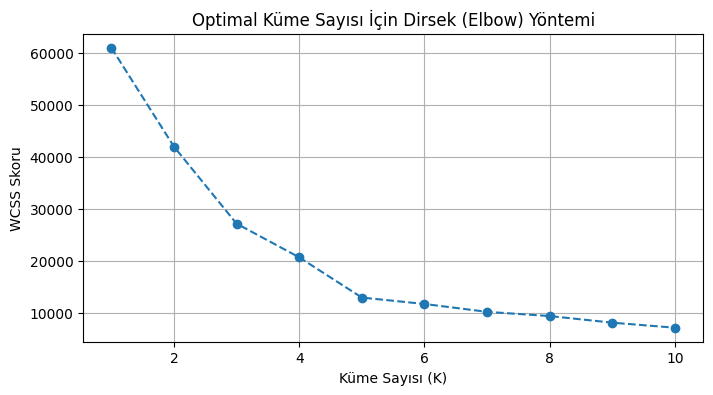

In [29]:
print("="*60)
print("🚀 GÖZETİMSİZ ÖĞRENME: K-MEANS KÜMELEME MODELİ")
print("="*60)

# Temizlenmiş veriyi okuyoruz
# Hatalı yol düzeltildi: ../../../ -> ../../
df_oyunlar = pd.read_csv("../../data/processed/oyunlar_temiz.csv")

# 1. Modelde kullanılacak özellikleri seçiyoruz ve eksik verileri (NaN) temizliyoruz
# (Fiyat sütunundaki NaN değerleri bu aşamada median veya 0 ile doldurulmalıdır)
# Hatalı sütun ismi düzeltildi: tehlikeli_kategori -> tehlikeli_kategorisi
df_model = df_oyunlar[['fiyat', 'yas_siniri', 'tehlikeli_kategorisi']].copy()
df_model['fiyat'] = df_model['fiyat'].fillna(df_model['fiyat'].median())

# 2. Ölçeklendirme (Scaling) İşlemi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

# 3. Elbow (Dirsek) Yöntemi ile Optimal Küme Sayısını Bulma
wcss = []
k_araligi = range(1, 11)

for k in k_araligi:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Dirsek Grafiğini Çizdirme
plt.figure(figsize=(8, 4))
plt.plot(k_araligi, wcss, marker='o', linestyle='--', color='#1f77b4')
plt.title('Optimal Küme Sayısı İçin Dirsek (Elbow) Yöntemi')
plt.xlabel('Küme Sayısı (K)')
plt.ylabel('WCSS Skoru')
plt.grid(True)
plt.show()

In [30]:
# Grafikten seçtiğimiz optimal küme sayısı (Örneğin 4 küme seçtiğimizi varsayalım)
optimal_k = 4

# Modelin oluşturulması
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df_oyunlar['kume_no'] = kmeans_final.fit_transform(X_scaled).argmax(axis=1) # ya da direkt .labels_

print("\n✅ Kümeleme işlemi tamamlandı! Küme dağılımları:")
print(df_oyunlar['kume_no'].value_counts())


✅ Kümeleme işlemi tamamlandı! Küme dağılımları:
kume_no
3    8707
2    6636
1    2699
0    2294
Name: count, dtype: int64


In [31]:
# Kümelerin profillerini inceleme
kume_profilleri = df_oyunlar.groupby('kume_no').agg(
    Ortalama_Fiyat=('fiyat', 'mean'),
    Ortalama_Yas_Siniri=('yas_siniri', 'mean'),
    Tehlikeli_Kategori_Orani=('tehlikeli_kategorisi', 'mean'), # Harf hatası düzeltildi
    Toplam_Oyun_Sayisi=('kume_no', 'count')
).reset_index()

display(kume_profilleri)

,kume_no,Ortalama_Fiyat,Ortalama_Yas_Siniri,Tehlikeli_Kategori_Orani,Toplam_Oyun_Sayisi
0,0,13.239227,14.799041,1.0,2294
1,1,4.761821,1.301593,1.0,2699
2,2,20.879843,13.297619,0.0,6636
3,3,7.426998,3.368899,0.0,8707


In [37]:
# ANVIA Game Insight segmentasyon profilleri
kume_isimleri_sozlugu = {
    0: "15+ Yaş Riskli İçerik",
    1: "12 Yaş Altı Riskli İçerik (Anomali)",
    2: "Premium / Güvenli Kategori",
    3: "Çocuk Dostu / Aile Bölgesi"
}

# Veri setine uygulama
df_oyunlar['Kume_Adi'] = df_oyunlar['kume_no'].map(kume_isimleri_sozlugu)
kume_profilleri['Kume_Adi'] = kume_profilleri['kume_no'].map(kume_isimleri_sozlugu)

In [38]:
print("="*60)
print("📊 PLOTLY İLE KÜME PROFİLLERİ GÖRSELLEŞTİRİLİYOR")
print("="*60)

# Kümeleri daha okunabilir yapmak için 'Küme 0', 'Küme 1' gibi isimler ekleyelim
kume_profilleri['Kume_Adi'] = "Küme " + kume_profilleri['kume_no'].astype(str)

# 4 Boyutlu Baloncuk Grafiği (Bubble Chart)
fig = px.scatter(
    kume_profilleri,
    x="Ortalama_Yas_Siniri",           # X Ekseni: Yaş
    y="Ortalama_Fiyat",                # Y Ekseni: Fiyat
    size="Toplam_Oyun_Sayisi",         # Balon Büyüklüğü: Kümeye düşen oyun sayısı
    color="Tehlikeli_Kategori_Orani",  # Renk: Tehlike oranı (Risk arttıkça renk değişir)
    hover_name="Kume_Adi",             # Üzerine gelince yazacak ana başlık
    text="kume_no",                    # Baloncukların içine küme numarasını yazar
    color_continuous_scale="Reds",     # Renk paleti (Tehlike arttıkça kırmızıya döner)
    size_max=70,                       # En büyük balonun maksimum boyutu
    title="🎯 Oyun Segmentleri: Yaş, Fiyat ve Risk Haritası",
    labels={
        "Ortalama_Yas_Siniri": "Ortalama Yaş Sınırı",
        "Ortalama_Fiyat": "Ortalama Fiyat",
        "Tehlikeli_Kategori_Orani": "Risk (Tehlike) Oranı",
        "Toplam_Oyun_Sayisi": "Oyun Sayısı"
    }
)

# Görseli daha şık ve kurumsal yapmak için arayüz dokunuşları
fig.update_traces(
    textposition='top center', 
    textfont_size=14, 
    marker=dict(line=dict(width=1, color='DarkSlateGrey')) # Balonların etrafına ince bir çizgi çeker
)

fig.update_layout(
    template="plotly_white",  # Arka planı temizler
    title_font_size=22,
    height=600
)

# Grafiği ekrana bas
fig.show()

📊 PLOTLY İLE KÜME PROFİLLERİ GÖRSELLEŞTİRİLİYOR


In [41]:
import plotly.express as px

print("="*60)
print("🦅 ANVIA GAME INSIGHT: KURUMSAL KÜME HARİTASI")
print("="*60)

# ANVIA Logo Renk Paleti (Hex Kodları)
# Küme numaralarına göre özel renk ataması yapıyoruz
anvia_renk_paleti = {
    "0": "#5AB9EA",  # Buz Mavisi (Kanatlardan)
    "1": "#D4AF37",  # Altın Sarısı (Çerçeve ve Yazıdan)
    "2": "#E0E6ED",  # Gümüş/Beyaz (Tüylerin parlayan kısımlarından)
    "3": "#187BCD"   # Derin Mavi (Arka planın canlı mavi tonlarından)
}

# 1. Veri Hazırlığı (Aynı yaş, fiyat ve kümeyi grupluyoruz)
df_balon = df_oyunlar.groupby(['yas_siniri', 'fiyat', 'kume_no', 'tehlikeli_kategorisi']).size().reset_index(name='Oyun_Sayisi')
df_balon['kume_no'] = df_balon['kume_no'].astype(str)

# 2. ANVIA Temalı Çizim
fig = px.scatter(
    df_balon,
    x="yas_siniri",
    y="fiyat",
    size="Oyun_Sayisi",
    color="kume_no",
    color_discrete_map=anvia_renk_paleti, # Logodan aldığımız renkleri uyguluyoruz
    hover_data=["tehlikeli_kategorisi", "Oyun_Sayisi"],
    size_max=50, 
    title="<b>ANVIA Game Insight: Yaş ve Risk Segmentasyonu</b>",
    labels={
        "yas_siniri": "Yaş Sınırı",
        "fiyat": "Fiyat (TL/USD)",
        "kume_no": "Oyuncu Personası (Küme)",
        "Oyun_Sayisi": "Oyun Sayısı"
    }
)

# 3. Koyu Tema ve Kurumsal Arayüz Güncellemesi
fig.update_layout(
    plot_bgcolor="#0A192F",  # Logonun arkasındaki o derin uzay laciverti
    paper_bgcolor="#0A192F", # Çerçevenin dışını da aynı lacivert yapıyoruz
    font=dict(color="#D4AF37", family="Arial"), # Yazıların tamamı Altın Sarısı
    title_font_size=24,
    height=650,
    legend=dict(
        title_font_color="#D4AF37",
        font=dict(color="#E0E6ED"),
        bgcolor="rgba(0,0,0,0)" # Efsane (Legend) arka planını şeffaf yapıyoruz
    ),
    xaxis=dict(showgrid=True, gridcolor="#1B2A47", gridwidth=0.5, title_font_color="#D4AF37"),
    yaxis=dict(showgrid=True, gridcolor="#1B2A47", gridwidth=0.5, title_font_color="#D4AF37")
)

# Balonların etrafına ince altın sarısı bir çizgi çekelim ki koyu temada patlasın
fig.update_traces(marker=dict(line=dict(width=1, color='#D4AF37')))

fig.show()

🦅 ANVIA GAME INSIGHT: KURUMSAL KÜME HARİTASI
